In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Create time series (hourly data for one cell)
time = pd.date_range(start="2026-06-15", periods=10, freq="H")

# Simulated increasing latency trend (cell degrading over time)
latency = [20, 22, 25, 30, 38, 45, 55, 70, 85, 95]

# Create DataFrame
df_ts = pd.DataFrame({
    "timestamp": time,
    "latency_ms": latency
})

# Show data
print(df_ts)

            timestamp  latency_ms
0 2026-06-15 00:00:00          20
1 2026-06-15 01:00:00          22
2 2026-06-15 02:00:00          25
3 2026-06-15 03:00:00          30
4 2026-06-15 04:00:00          38
5 2026-06-15 05:00:00          45
6 2026-06-15 06:00:00          55
7 2026-06-15 07:00:00          70
8 2026-06-15 08:00:00          85
9 2026-06-15 09:00:00          95


C:\Users\azeem\AppData\Local\Temp\ipykernel_11052\671157399.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time = pd.date_range(start="2026-06-15", periods=10, freq="H")


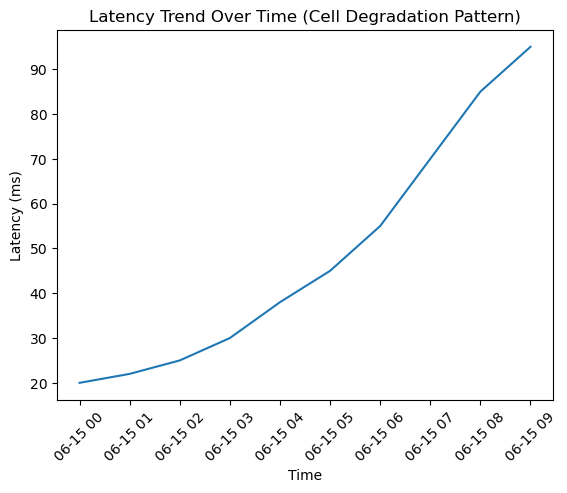

In [2]:
import matplotlib.pyplot as plt

plt.figure()

# Plot latency over time
plt.plot(
    df_ts["timestamp"],
    df_ts["latency_ms"]
)

plt.title("Latency Trend Over Time (Cell Degradation Pattern)")
plt.xlabel("Time")
plt.ylabel("Latency (ms)")

plt.xticks(rotation=45)

plt.show()

In [3]:
# We use last 3 values to predict next value

df_ts["rolling_avg"] = df_ts["latency_ms"].rolling(window=3).mean()

print(df_ts)

            timestamp  latency_ms  rolling_avg
0 2026-06-15 00:00:00          20          NaN
1 2026-06-15 01:00:00          22          NaN
2 2026-06-15 02:00:00          25    22.333333
3 2026-06-15 03:00:00          30    25.666667
4 2026-06-15 04:00:00          38    31.000000
5 2026-06-15 05:00:00          45    37.666667
6 2026-06-15 06:00:00          55    46.000000
7 2026-06-15 07:00:00          70    56.666667
8 2026-06-15 08:00:00          85    70.000000
9 2026-06-15 09:00:00          95    83.333333


In [4]:
# Take last 3 latency values
last_values = df_ts["latency_ms"].tail(3)

# Predict next value as average of last 3
predicted_latency = last_values.mean()

print("Predicted next-hour latency:", round(predicted_latency, 2))

Predicted next-hour latency: 83.33


In [5]:
# Function to classify future risk

def forecast_risk(predicted_latency):

    # If latency is very high → future outage risk
    if predicted_latency > 80:
        return "CRITICAL RISK (Expected outage)"

    # Moderate degradation
    elif predicted_latency > 50:
        return "WARNING (Degrading cell)"

    # Normal condition
    else:
        return "STABLE"

# Apply risk classification
risk = forecast_risk(predicted_latency)

print("Forecast Status:", risk)

Forecast Status: CRITICAL RISK (Expected outage)


In [6]:
# Import libraries
import pandas as pd
import numpy as np

# Create time steps (0 → 9 hours)
# Each number represents an hour index
hours = np.arange(0, 10)

# Simulated latency trend (cell degrading over time)
latency = [18, 20, 23, 28, 35, 44, 55, 68, 82, 95]

# Create DataFrame
df_ml = pd.DataFrame({
    "hour": hours,
    "latency_ms": latency
})

# Display dataset
print(df_ml)

   hour  latency_ms
0     0          18
1     1          20
2     2          23
3     3          28
4     4          35
5     5          44
6     6          55
7     7          68
8     8          82
9     9          95


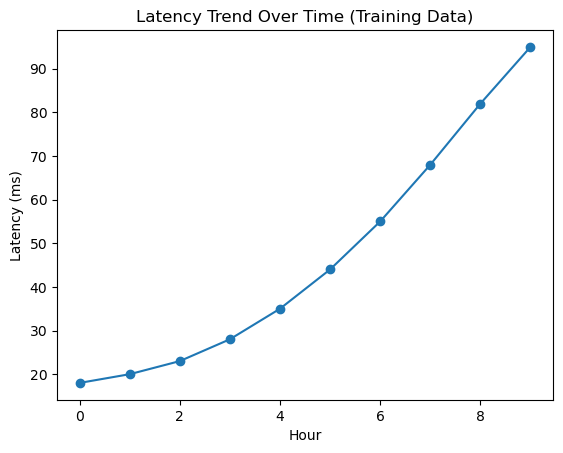

In [7]:
import matplotlib.pyplot as plt

plt.figure()

# Plot real latency values
plt.plot(df_ml["hour"], df_ml["latency_ms"], marker="o")

plt.title("Latency Trend Over Time (Training Data)")
plt.xlabel("Hour")
plt.ylabel("Latency (ms)")

plt.show()

In [8]:
# Import ML model
from sklearn.linear_model import LinearRegression

# Reshape data for sklearn
# X must be 2D (matrix format)
X = df_ml[["hour"]]          # input feature
y = df_ml["latency_ms"]      # target output

# Create model
model = LinearRegression()

# Train model
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# Future time points
future_hours = pd.DataFrame({
    "hour": [10, 11, 12]
})

# Predict latency
future_predictions = model.predict(future_hours)

# Show results
print("Future Predictions:")
for h, pred in zip(future_hours["hour"], future_predictions):
    print(f"Hour {h} → Latency {round(pred, 2)} ms")

Future Predictions:
Hour 10 → Latency 94.87 ms
Hour 11 → Latency 103.61 ms
Hour 12 → Latency 112.35 ms


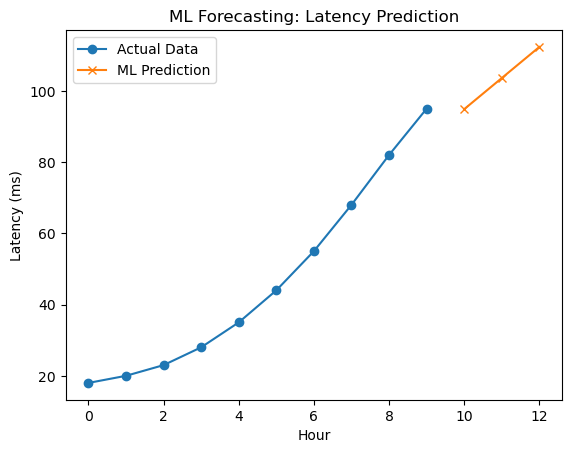

In [10]:
plt.figure()

# Plot real data
plt.plot(df_ml["hour"], df_ml["latency_ms"], label="Actual Data", marker="o")

# Plot prediction
plt.plot(future_hours["hour"], future_predictions, label="ML Prediction", marker="x")

plt.title("ML Forecasting: Latency Prediction")
plt.xlabel("Hour")
plt.ylabel("Latency (ms)")

plt.legend()
plt.show()

In [11]:
# Function to classify predicted risk

def classify_risk(predicted_latency):

    if predicted_latency > 90:
        return "CRITICAL (Expected Failure)"

    elif predicted_latency > 60:
        return "WARNING (Degrading)"

    else:
        return "STABLE"

# Apply to all predictions
for h, pred in zip(future_hours["hour"], future_predictions):
    print(f"Hour {h} → {classify_risk(pred)}")

Hour 10 → CRITICAL (Expected Failure)
Hour 11 → CRITICAL (Expected Failure)
Hour 12 → CRITICAL (Expected Failure)


In [12]:
# Import libraries
import pandas as pd
import numpy as np

# Create time index (10 hours)
hours = np.arange(0, 10)

# Simulated telecom KPIs showing degradation pattern
df_multi = pd.DataFrame({

    # Time index (hourly progression)
    "hour": hours,

    # Latency increases over time (network congestion starts building)
    "latency_ms": [18, 20, 24, 30, 38, 48, 60, 75, 90, 105],

    # Packet loss increases (sign of transport or congestion issues)
    "packet_loss": [0.1, 0.1, 0.2, 0.3, 0.6, 1.2, 2.0, 3.5, 5.0, 7.0],

    # PRB utilization increases (radio congestion)
    "prb_utilization": [55, 58, 60, 65, 72, 80, 88, 92, 96, 99]
})

# Display dataset
print(df_multi)

   hour  latency_ms  packet_loss  prb_utilization
0     0          18          0.1               55
1     1          20          0.1               58
2     2          24          0.2               60
3     3          30          0.3               65
4     4          38          0.6               72
5     5          48          1.2               80
6     6          60          2.0               88
7     7          75          3.5               92
8     8          90          5.0               96
9     9         105          7.0               99


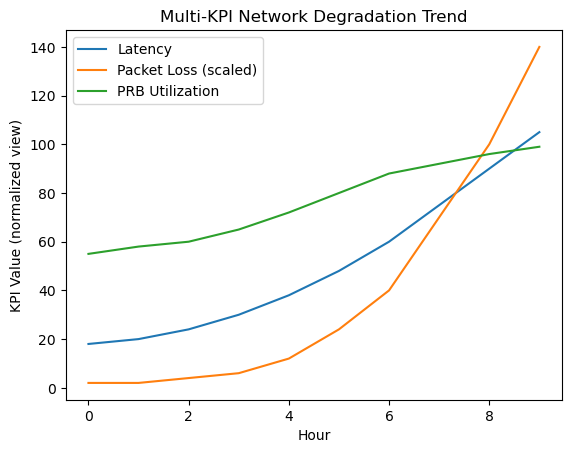

In [14]:
import matplotlib.pyplot as plt

plt.figure()

# Plot latency trend
plt.plot(df_multi["hour"], df_multi["latency_ms"], label="Latency")

# Plot packet loss trend
plt.plot(df_multi["hour"], df_multi["packet_loss"] * 20, label="Packet Loss (scaled)")

# Plot PRB trend
plt.plot(df_multi["hour"], df_multi["prb_utilization"], label="PRB Utilization")

plt.title("Multi-KPI Network Degradation Trend")
plt.xlabel("Hour")
plt.ylabel("KPI Value (normalized view)")
plt.legend()

plt.show()

In [15]:
# Feature set (inputs)
X = df_multi[["hour", "packet_loss", "prb_utilization"]]

# Target (what we want to predict)
y = df_multi["latency_ms"]

In [16]:
from sklearn.ensemble import RandomForestRegressor

# Create model
model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    random_state=42
)

# Train model
model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
# Future scenario (next 3 hours)
future_data = pd.DataFrame({

    "hour": [10, 11, 12],

    # Assumed worsening conditions
    "packet_loss": [7.5, 8.0, 9.0],

    "prb_utilization": [99, 99, 100]
})

# Predict future latency
future_latency = model.predict(future_data)

# Show results
for i in range(len(future_data)):
    print(
        f"Hour {future_data['hour'][i]} → "
        f"Predicted Latency: {round(future_latency[i], 2)} ms"
    )

Hour 10 → Predicted Latency: 96.96 ms
Hour 11 → Predicted Latency: 96.96 ms
Hour 12 → Predicted Latency: 96.96 ms


In [18]:
# Function to classify future risk

def classify_network_risk(latency):

    # Critical failure zone
    if latency > 90:
        return "CRITICAL - Network Failure Likely"

    # Degraded performance
    elif latency > 60:
        return "WARNING - Network Degrading"

    # Stable network
    else:
        return "STABLE"

# Apply classification
for i in range(len(future_data)):

    risk = classify_network_risk(future_latency[i])

    print(
        f"Hour {future_data['hour'][i]} → {risk}"
    )

Hour 10 → CRITICAL - Network Failure Likely
Hour 11 → CRITICAL - Network Failure Likely
Hour 12 → CRITICAL - Network Failure Likely


In [19]:
import pandas as pd
import numpy as np

# Simulate 5 cells (extendable to 100k+ in real system)
cells = ["Cell_A", "Cell_B", "Cell_C", "Cell_D", "Cell_E"]

data = []

# Generate multi-cell multi-KPI dataset
for cell in cells:

    for hour in range(10):

        data.append([
            cell,
            hour,

            # Simulated KPIs (different patterns per cell)
            np.random.randint(10, 100),   # latency
            np.random.uniform(0, 8),      # packet loss
            np.random.randint(50, 100)    # PRB utilization
        ])

# Create DataFrame
df_cells = pd.DataFrame(data, columns=[
    "cell_id",
    "hour",
    "latency_ms",
    "packet_loss",
    "prb_utilization"
])

# Show dataset
print(df_cells.head(10))

  cell_id  hour  latency_ms  packet_loss  prb_utilization
0  Cell_A     0          87     0.087812               58
1  Cell_A     1          62     7.815442               56
2  Cell_A     2          24     5.072066               81
3  Cell_A     3          44     1.573094               64
4  Cell_A     4          69     4.816977               76
5  Cell_A     5          45     1.960764               90
6  Cell_A     6          96     2.695383               99
7  Cell_A     7          22     4.936879               76
8  Cell_A     8          77     0.439111               92
9  Cell_A     9          48     2.923058               94


In [20]:
from sklearn.ensemble import RandomForestRegressor

# Convert categorical cell_id into numeric (simple encoding)
df_cells["cell_encoded"] = df_cells["cell_id"].astype("category").cat.codes

# Features (input)
X = df_cells[[
    "cell_encoded",
    "hour",
    "packet_loss",
    "prb_utilization"
]]

# Target (output)
y = df_cells["latency_ms"]

# Create model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model on ALL cells together
model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
# Take latest state of each cell
latest_data = df_cells[df_cells["hour"] == 9].copy()

# Encode cell_id again
latest_data["cell_encoded"] = latest_data["cell_id"].astype("category").cat.codes

# Create future scenario (hour = 10)
latest_data["hour"] = 10

# Features for prediction
X_future = latest_data[[
    "cell_encoded",
    "hour",
    "packet_loss",
    "prb_utilization"
]]

# Predict future latency for ALL cells
latest_data["predicted_latency"] = model.predict(X_future)

# Show results
print(latest_data[[
    "cell_id",
    "predicted_latency"
]])

   cell_id  predicted_latency
9   Cell_A              51.92
19  Cell_B              73.25
29  Cell_C              48.20
39  Cell_D              37.62
49  Cell_E              73.60


In [22]:
def risk_level(latency):

    if latency > 85:
        return "CRITICAL"

    elif latency > 60:
        return "WARNING"

    else:
        return "STABLE"

# Apply risk classification
latest_data["risk"] = latest_data["predicted_latency"].apply(risk_level)

# Show final output
print(latest_data[[
    "cell_id",
    "predicted_latency",
    "risk"
]])

   cell_id  predicted_latency     risk
9   Cell_A              51.92   STABLE
19  Cell_B              73.25  WARNING
29  Cell_C              48.20   STABLE
39  Cell_D              37.62   STABLE
49  Cell_E              73.60  WARNING
